[&#8592; Previous: Unsupervised Learning](03_unsupervised_learning.ipynb)

# **Supervised Learning: MIPS Performance vs County Medicare Outcomes**

---

**The goal.** Test whether regional MIPS physician group performance tracks county Medicare
readmissions beyond demographics, and characterize that association honestly. Readmissions are the
primary outcome throughout. Standardized cost per beneficiary is carried as a secondary outcome so
the same models can be read against a second target, but it measures spending rather than health and
is not the question this project asks; the executive summary reports what it shows and why it is not
built on.

**What we find.** A small association that is essentially absorbed once we adjust for the county's own prior-year outcomes. The executive summary below gives the numbers, evidence, and caveats.

**The approach.** Cross-sectional county regression on 2023 data: four estimators in three families
(predictive linear, Elastic Net, and two tree ensembles), plus per-measure cluster-robust OLS models for
measure-level inference in section 10, each predictive model fit with and without MIPS under state-grouped
cross-validation.

**Inputs** (see `data/manifest.yaml` for pins):
- `data/processed/analytic_measure.csv.gz` : county x measure table from the crosswalk pipeline
- `data/processed/county_clusters.csv` : county cluster labels from the unsupervised notebook
- `data/raw/grp_public_reporting.csv` : source of the inverse measure flags

**Setup:** Pinned dependencies: `python -m pip install -r ../requirements.txt`
(polars and statsmodels are included there for this notebook).

[Next: Supervised Learning Extensions &#8594;](05_supervised_learning_extensions.ipynb)

---
## **Executive summary**

**County-level MIPS aggregates are too thin to support regional quality inference: two thirds of
county measure cells rest on two or fewer reporting practices, and reporting pattern alone recovers
most of the tree model's lift. The association that survives is small (Elastic Net delta R2 = +0.017,
95% CI touching zero) and is absorbed by the county's own prior-year readmission rate, which is what a
mostly-noise exposure predicts. This is a claim about the county aggregate, not about MIPS at the
practice level where the program operates.**

| Finding | Evidence |
|---|---|
| A small association at the significance boundary | Elastic Net delta R2 = +0.017 (1.7% of variance), robust to demographics and specialty mix (and to population weighting in the extensions notebook); but 95% CI [-0.000, +0.035] includes zero and paired t(4) = 2.78, p = 0.050 is exactly at threshold; the full model still leaves ~85% of variance unexplained |
| It is cross-sectional, not a forward effect | present across 2022, 2023, and 2024 outcomes (largest for 2022) against fixed PY2023 features, so it is a stable feature of the county rather than an effect of that year's performance |
| It adds essentially nothing beyond outcome history | adding the county's 2022 readmission rate absorbs it (the increment goes from +0.006 to +0.002 on that sample) because MIPS quality and readmissions are both stable county traits; this shows redundancy with outcome history, not that the association is spurious |
| Ranked measures are preventive and point one way | each measure is fitted in its own state-clustered model, and of the 16 clearing a 70% coverage floor, 3 survive BH FDR: HbA1c poor control (001, q = 0.0069), cervical cancer screening (309, q = 0.0069), breast cancer screening (112, q = 0.0374). All three point the sensible way (better performance -> fewer readmissions) and rest on 78% to 91% observed data; a small, uniform, primary care set |
| Much of the cross-sectional lift is reporting pattern | for gradient boosting, county missingness indicators alone recover about 80% of the lift |
| The exposure is too sparse to carry regional signal | 52.0% of county x measure cells rest on a single reporting practice and 69.2% on two or fewer; 33 of 49 screened measures fall below 70% county coverage (median 54.3%); 690 of 3,197 counties cannot be modeled at all. Noise of this kind biases a true effect toward zero, so +0.017 is likely an underestimate, though self-selected reporting makes the error non-classical and the direction is not guaranteed |

**Note on the cost target.** Standardized cost per beneficiary is a secondary outcome and is not
built on, for three tested reasons rather than one asserted. Its largest increment is bigger than the
readmission headline (gradient boosting +0.062 against +0.017) but far less certain: 95% CI
[-0.004, +0.128], p = 0.060, an interval roughly ten times wider that still crosses zero. The same
missingness ablation applied to readmissions recovers 42 to 51% of that lift from reporting indicators
alone. And it measures spending rather than patient health, so it answers a different question than
this project asks.

## Table of Contents

1. [Setup and load](#s1)
2. [Filter to the modeling year](#s2)
3. [Feature matrix](#s3)
4. [Leakage screen](#s4)
5. [Direction alignment, controls, and targets](#s5)
6. [Validation design](#s6)
7. [The model ladder, with vs without MIPS](#s7)
8. [Headline: does MIPS add value?](#s8)
9. [Does MIPS add anything beyond a county's own past readmissions?](#s8b)
10. [Explanatory model: which measures matter](#s9)
11. [Cluster tie in and residual checks](#s10)
12. [Export and summary](#s11)

---
<a id="s1"></a>

## **1. Setup and load**

Load only the columns this analysis needs. Everything reads as text first so zero padded
identifiers survive, then numeric columns are cast explicitly ("NA" and "*" become nulls).

In [1]:
# Standard Library
import gzip
from pathlib import Path

# Data Processing
import numpy as np
import polars as pl

# Visualization
import matplotlib.pyplot as plt

DATA = Path("../data")
FIGURES = Path("../reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

BLUE, MAIZE = "#00274C", "#FFCB05"
GRAY = "#9aa0a6"

# Shared report style: clean spines, light grid, on-brand colors
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "svg.hashsalt": "healthcare-heroes",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": BLUE,
    "axes.edgecolor": "#bbbbbb",
    "axes.linewidth": 1.0,
    "xtick.color": "#444444",
    "ytick.color": "#444444",
})

MODEL_NAMES = {"linear": "Linear (OLS)", "elastic_net": "Elastic Net",
               "random_forest": "Random Forest", "grad_boost": "Gradient Boosting"}
TARGET_NAMES = {"readmission_pct": "Hospital readmissions",
                "stdzd_cost_pc": "Standardized cost per beneficiary"}

def clean_ax(ax, grid_axis="x"):
    """Drop top/right spines and add a light grid for a report look."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    if grid_axis:
        ax.grid(axis=grid_axis, color="#dddddd", linewidth=0.8, zorder=0)
        ax.set_axisbelow(True)

RANDOM_STATE = 42
MODEL_YEAR = "2023"

CONTROL_COLS = [
    "BENE_AVG_AGE", "BENE_FEML_PCT", "BENE_RACE_WHT_PCT", "BENE_RACE_BLACK_PCT",
    "BENE_RACE_HSPNC_PCT", "BENE_DUAL_PCT", "MA_PRTCPTN_RATE", "BENES_TOTAL_CNT",
]
TARGETS = {
    "readmission_pct": "ACUTE_HOSP_READMSN_PCT",
    "stdzd_cost_pc": "TOT_MDCR_STDZD_PYMT_PC",
}

LOAD_COLS = [
    "county_fips", "YEAR", "BENE_AGE_LVL", "BENE_GEO_DESC",
    "measure_cd", "measure_title", "avg_prf_rate_weighted",
    *CONTROL_COLS, *TARGETS.values(),
]

# county x measure table built by the 02_zip_county_crosswalk pipeline
# (MIPS -> DAC -> HUD ZIP crosswalk -> county, tot_ratio-weighted aggregation)
with gzip.open(DATA / "processed" / "analytic_measure.csv.gz", "rb") as f:
    am = pl.read_csv(f.read(), columns=LOAD_COLS, infer_schema_length=0)

print(f"loaded {am.height:,} rows x {am.width} cols")
print(f"years present: {sorted(am['YEAR'].unique().to_list())}")

loaded 1,611,053 rows x 17 cols
years present: ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


---
<a id="s2"></a>

## **2. Filter to the modeling year**

2023 matches the MIPS performance year. County rows in the geo file carry a single age level,
which the assert below verifies instead of assuming. Note the grain here is one row per
county x measure (tidy long format); it collapses to one row per county at the pivot in section 3.

In [2]:
# lock the panel to the MIPS performance year and verify the grain
am23 = am.filter(pl.col("YEAR") == MODEL_YEAR)

age_levels = sorted(am23["BENE_AGE_LVL"].unique().to_list())
assert age_levels == ["All"], f"unexpected age levels: {age_levels}"

dup = am23.group_by("county_fips", "measure_cd").len().filter(pl.col("len") > 1)
assert dup.height == 0, f"{dup.height} duplicate county x measure rows"

with_mips = am23.filter(pl.col("measure_cd").is_not_null() & (pl.col("measure_cd") != ""))
print(f"{MODEL_YEAR} rows: {am23.height:,}")
print(f"counties: {am23['county_fips'].n_unique():,}")
print(f"rows with MIPS data: {with_mips.height:,}")
print(f"distinct measures: {with_mips['measure_cd'].n_unique()}")

2023 rows: 147,196
counties: 3,197
rows with MIPS data: 146,954
distinct measures: 229


---
<a id="s3"></a>

## **3. Feature matrix**

Pivot to county x measure, then apply the team coverage thresholds (measures reported in at
least 30% of counties, counties reporting at least 20% of measures). One deliberate difference
from the unsupervised notebook: the county threshold here is computed over the 55 surviving
measures rather than all 229, which keeps ~2,500 counties instead of 1,400. More counties means
more statistical power and less urban selection; the cost is a higher imputed share, which the
sensitivity note in the limitations covers.

In [3]:
# coverage thresholds follow the 03_unsupervised_learning notebook (30% / 20%) so the
# Two analyses stay comparable; county coverage here is computed over surviving
# Measures, which keeps more counties (difference explained in the markdown above)
MEASURE_THRESH, COUNTY_THRESH = 0.30, 0.20

wide = (
    with_mips
    .with_columns(pl.col("avg_prf_rate_weighted").cast(pl.Float64, strict=False))
    .pivot(on="measure_cd", index="county_fips", values="avg_prf_rate_weighted")
)
measure_cols = [c for c in wide.columns if c != "county_fips"]
print(f"pivoted: {wide.height:,} counties x {len(measure_cols)} measures")

coverage = {
    c: wide[c].is_not_null().sum() / wide.height
    for c in measure_cols
}
keep_measures = [c for c, f in coverage.items() if f >= MEASURE_THRESH]

wide = wide.select("county_fips", *keep_measures).with_columns(
    row_cov=pl.mean_horizontal([pl.col(c).is_not_null().cast(pl.Float64) for c in keep_measures])
).filter(pl.col("row_cov") >= COUNTY_THRESH).drop("row_cov")

null_frac = wide.select(keep_measures).null_count().sum_horizontal().item() / (wide.height * len(keep_measures))
print(f"after coverage filter: {wide.height:,} counties x {len(keep_measures)} measures")
print(f"remaining missing cells: {null_frac:.1%} (median-imputed inside each model pipeline)")

pivoted: 2,955 counties x 229 measures
after coverage filter: 2,507 counties x 55 measures
remaining missing cells: 36.0% (median-imputed inside each model pipeline)


---
<a id="s4"></a>

## **4. Leakage screen**

Three guards before any model sees the data:

1. **Circular measures**: a readmission flavored MIPS measure must not predict a readmission target.
2. **Sibling strata**: `_overall` vs `_screened` style codes are the same construct sliced twice; keep one.
   Codes whose final token is a number (like `PI_GRP_HIE_1` vs `PI_GRP_HIE_4`) are distinct measures,
   not strata, and are never consolidated.
3. **Identity features**: geography never enters X, it only shapes the CV folds.

The screen is pattern based on measure titles; MIPS_GRP_357 (surgical site infection) survives it
and is retained deliberately: infection is a process adjacent complication measured on a clinical
denominator, not a claims defined readmission event.

To back the keyword screen, all surviving features were manually type classified: of the 49, none
is a claims based outcome measure (38 process, 7 clinical intermediate outcome such as HbA1c or
blood pressure control, 4 structural/attestation from the Promoting Interoperability program). The
two genuine claims based outcome measures that reached the candidate pool, MIPS_GRP_479
(30 day all cause readmission) and MIPS_GRP_480 (risk standardized complication rate), were both
removed by the screen above. The keyword list is not exhaustive on its own, so this manual
classification is the backstop.

In [4]:
# drop anything that could smuggle the outcome into X
CIRCULAR_PATTERNS = ["readmission", "admission", "emergency department", "hospitalization",
                     "complication", "risk-standardized", "mortality"]

titles = dict(
    with_mips.select("measure_cd", "measure_title").unique(subset=["measure_cd"]).iter_rows()
)

dropped_circular = [
    c for c in keep_measures
    if any(p in (titles.get(c) or "").lower() for p in CIRCULAR_PATTERNS)
]
print("dropped as outcome-adjacent (circular):")
for c in dropped_circular:
    print(f"  {c}: {titles.get(c, '')[:90]}")

survivors = [c for c in keep_measures if c not in dropped_circular]

def base_of(c):
    """Return the measure family used for stratum consolidation.

    Args:
        c: Measure code, like "MIPS_GRP_226_screened" or "PI_GRP_HIE_1".

    Returns:
        The code without its stratum suffix. Codes whose final token is a
        number are distinct measures, not strata, and come back unchanged.
    """
    head, _, tail = c.rpartition("_")
    return head if (tail and not tail.isdigit()) else c

by_base = {}
for c in survivors:
    by_base.setdefault(base_of(c), []).append(c)

dropped_siblings = []
final_measures = []
for base, sibs in by_base.items():
    if len(sibs) == 1:
        final_measures.append(sibs[0])
        continue
    overall = [c for c in sibs if c.endswith("_overall")]
    keep = overall[0] if overall else max(sibs, key=lambda c: coverage[c])
    final_measures.append(keep)
    dropped_siblings += [c for c in sibs if c != keep]

print(f"\nsibling strata consolidated ({len(dropped_siblings)} dropped):")
for c in dropped_siblings:
    print(f"  {c}")

assert not any(c in final_measures for c in ("county_fips", "BENE_GEO_DESC"))
X_wide = wide.select("county_fips", *final_measures)
print(f"\nfinal feature matrix: {X_wide.height:,} counties x {len(final_measures)} MIPS measures")

dropped as outcome-adjacent (circular):
  MIPS_GRP_479_overall: Hospital-Wide, 30-Day, All-Cause Unplanned Readmission (HWR) Rate for the Merit-Based Ince
  MIPS_GRP_480_overall: Risk-standardized complication rate (RSCR) following elective primary total hip arthroplas

sibling strata consolidated (4 dropped):
  MIPS_GRP_226_combinedPopulations
  MIPS_GRP_226_screened
  MIPS_GRP_238_appropriateDiagnosis
  MIPS_GRP_238_totalRate

final feature matrix: 2,507 counties x 49 MIPS measures


---
<a id="s5"></a>

## **5. Direction alignment, controls, and targets**

The raw MIPS file flags inverse measures (`invs_msr = Y`, like HbA1c poor control where higher is
worse). Models do not care about sign, but coefficients do: every displayed coefficient below is
sign adjusted so it always reads "per 1 SD **better** performance." Mixed scales across measures
are handled by per measure standardization, never by `100 - x` arithmetic.

Control caveat: `MA_PRTCPTN_RATE` (Medicare Advantage share) is a useful composition control for
FFS based outcomes but is plausibly endogenous to local practice patterns; the increment is rechecked on the complete demographics subset (counties with no imputed race or MA share) in the sensitivity block.

Provider composition is also a confounder: counties leaning specialist versus primary care differ
systematically in both MIPS reporting and outcomes. We add two composition controls built from the
DAC provider file, aggregated to county through the same ZIP to county crosswalk as the MIPS rollup:
the share of providers in primary care and the share in advanced practice (NP/PA). The DAC is a
current snapshot, so this composition is treated as a slowly varying county trait rather than a
2023 specific measurement.

In [5]:
def build_county_specialty(data_dir):
    """Build county provider-composition shares from the DAC provider file.

    Aggregates individual providers to county through the HUD ZIP-to-county
    crosswalk (tot_ratio weighted, matching the MIPS rollup) and returns the
    share of providers in primary care and in advanced practice per county.

    Args:
        data_dir: Path to the data directory (expects raw/ and interim/).

    Returns:
        Polars DataFrame with county_fips, pct_primary_care, pct_advanced_practice.
    """
    primary = ["FAMILY PRACTICE", "INTERNAL MEDICINE", "GENERAL PRACTICE", "GERIATRIC MEDICINE"]
    advanced = ["NURSE PRACTITIONER", "PHYSICIAN ASSISTANT"]
    dac = (
        pl.read_csv(data_dir / "raw" / "DAC_NationalDownloadableFile.csv",
                    columns=["NPI", "pri_spec", "ZIP Code"], infer_schema_length=0)
        .drop_nulls(["NPI", "pri_spec", "ZIP Code"])
        .with_columns(zip5=pl.col("ZIP Code").str.slice(0, 5))
        .unique(subset=["NPI", "zip5"])
        .with_columns(
            cat=pl.when(pl.col("pri_spec").is_in(primary)).then(pl.lit("primary_care"))
                 .when(pl.col("pri_spec").is_in(advanced)).then(pl.lit("advanced_practice"))
                 .otherwise(pl.lit("other"))
        )
    )
    xwalk = (
        pl.read_csv(data_dir / "raw" / "ZIP-COUNTY.csv",
                    columns=["zip", "geoid", "tot_ratio"], infer_schema_length=0)
        .with_columns(
            zip5=pl.col("zip").str.zfill(5),
            county_fips=pl.col("geoid").str.zfill(5),
            tot_ratio=pl.col("tot_ratio").cast(pl.Float64, strict=False),
        )
    )
    agg = (
        dac.join(xwalk.select("zip5", "county_fips", "tot_ratio"), on="zip5", how="inner")
        .group_by("county_fips", "cat").agg(w=pl.col("tot_ratio").sum())
        .pivot(on="cat", index="county_fips", values="w").fill_null(0.0)
    )
    total = pl.col("primary_care") + pl.col("advanced_practice") + pl.col("other")
    return agg.with_columns(
        pct_primary_care=pl.col("primary_care") / total,
        pct_advanced_practice=pl.col("advanced_practice") / total,
    ).select("county_fips", "pct_primary_care", "pct_advanced_practice")


# inverse-measure flags live only in the raw MIPS file (headers ship with leading spaces)
grp = pl.read_csv(DATA / "raw" / "grp_public_reporting.csv", infer_schema_length=0)
grp = grp.rename({c: c.strip() for c in grp.columns})
invs_map = dict(grp.select("measure_cd", "invs_msr").unique(subset=["measure_cd"]).iter_rows())

flip_sign = {c: (-1.0 if invs_map.get(c) == "Y" else 1.0) for c in final_measures}
n_flipped = sum(1 for s in flip_sign.values() if s < 0)
print(f"inverse measures among features: {n_flipped} (signs adjusted at display time)")

county_frame = (
    am23
    .unique(subset=["county_fips"], keep="first")
    .select("county_fips", "BENE_GEO_DESC", *CONTROL_COLS, *TARGETS.values())
    .with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in [*CONTROL_COLS, *TARGETS.values()]])
    .with_columns(pl.col("BENES_TOTAL_CNT").log().alias("log_benes"))
    .drop("BENES_TOTAL_CNT")
)
CONTROLS = [c for c in CONTROL_COLS if c != "BENES_TOTAL_CNT"] + ["log_benes"]

# Provider composition: load the cached shares, or rebuild from the DAC if absent
SPECIALTY_PATH = DATA / "interim" / "county_specialty.csv"
if SPECIALTY_PATH.exists():
    specialty = pl.read_csv(SPECIALTY_PATH, infer_schema_length=0).with_columns(
        pl.col("county_fips").str.zfill(5),
        pl.col("pct_primary_care").cast(pl.Float64),
        pl.col("pct_advanced_practice").cast(pl.Float64),
    )
else:
    specialty = build_county_specialty(DATA)
SPECIALTY_COLS = ["pct_primary_care", "pct_advanced_practice"]

frame = (
    county_frame.join(X_wide, on="county_fips", how="inner")
    .join(specialty.select("county_fips", *SPECIALTY_COLS), on="county_fips", how="left")
    .with_columns(
        state=pl.col("county_fips").str.slice(0, 2),
        race_ctrl_missing=pl.col("BENE_RACE_WHT_PCT").is_null().cast(pl.Float64),
    )
    .sort("county_fips")
)
CONTROLS = CONTROLS + SPECIALTY_COLS
n_spec = frame["pct_primary_care"].is_not_null().sum()
print(f"modeling frame: {frame.height:,} counties, {frame['state'].n_unique()} states")
print(f"specialty controls joined: {n_spec:,}/{frame.height:,} counties have provider composition")

for name, col in TARGETS.items():
    n_ok = frame[col].is_not_null().sum()
    print(f"target {name} ({col}): {n_ok:,} counties with values")
miss_ctrl = {c: frame[c].null_count() for c in CONTROLS if frame[c].null_count() > 0}
print(f"controls with any missing values: {miss_ctrl if miss_ctrl else 'none'}")

inverse measures among features: 6 (signs adjusted at display time)
modeling frame: 2,507 counties, 51 states
specialty controls joined: 2,507/2,507 counties have provider composition
target readmission_pct (ACUTE_HOSP_READMSN_PCT): 2,458 counties with values
target stdzd_cost_pc (TOT_MDCR_STDZD_PYMT_PC): 2,507 counties with values
controls with any missing values: {'BENE_RACE_WHT_PCT': 871, 'BENE_RACE_BLACK_PCT': 871, 'BENE_RACE_HSPNC_PCT': 871, 'BENE_DUAL_PCT': 8, 'MA_PRTCPTN_RATE': 2}


---
<a id="s6"></a>

## **6. Validation design**

`GroupKFold` with **state** as the group: a model is always scored on states it never trained on,
which keeps spatially correlated neighbors out of the training folds. The same folds are reused
for every model so comparisons are apples to apples. The mean predictor sets the floor.

Two footnotes on reading the scores. ElasticNetCV tunes its penalty with an inner ungrouped
K fold on the training rows; the outer grouped folds still guarantee the reported scores are
computed on unseen states, so this affects tuning quality, not score validity. And baseline R2
values come out slightly negative under grouped CV: each fold's test states have a different mean
than the training states, so predicting the training mean scores below zero. That is expected and
makes the baseline an honest floor.

In [6]:
# Machine Learning
from sklearn.model_selection import GroupKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# Shared CV design: every model is scored on the exact same state-grouped folds,
# So with-vs-without MIPS is a paired comparison
SCORING = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
}
N_SPLITS = 5

def make_pipe(model):
    """Wrap an estimator with the shared preprocessing steps.

    Args:
        model: An unfitted sklearn estimator.

    Returns:
        Pipeline of median imputation, standardization, then the model, so
        preprocessing is fitted inside each training fold only.
    """
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("model", model),
    ])

MODELS = {
    "baseline_mean": lambda: DummyRegressor(strategy="mean"),
    "linear": lambda: LinearRegression(),
    "elastic_net": lambda: ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9, 1.0], alphas=50,
                                        max_iter=5000, random_state=RANDOM_STATE),
    "random_forest": lambda: RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                                   n_jobs=-1, random_state=RANDOM_STATE),
    "grad_boost": lambda: HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}
FEATURE_SETS = {
    "controls_only": CONTROLS + ["race_ctrl_missing"],
    "controls_plus_mips": CONTROLS + ["race_ctrl_missing"] + final_measures,
}

def target_arrays(target_col):
    """Build the modeling arrays and grouped CV folds for one target.

    Args:
        target_col: Column name of the outcome in the modeling frame.

    Returns:
        Tuple of (county subset, feature DataFrame, target array, state
        groups, list of GroupKFold train/test index pairs). The folds are
        materialized once so every model scores on identical splits.
    """
    sub = frame.filter(pl.col(target_col).is_not_null())
    X_pd = sub.select(FEATURE_SETS["controls_plus_mips"]).to_pandas()
    y = sub[target_col].to_numpy()
    groups = sub["state"].to_numpy()
    folds = list(GroupKFold(n_splits=N_SPLITS).split(X_pd, y, groups))
    return sub, X_pd, y, groups, folds

fold_info = {}
for name, col in TARGETS.items():
    sub, X_pd, y, groups, folds = target_arrays(col)
    fold_info[name] = (sub, X_pd, y, groups, folds)
    sizes = [len(te) for _, te in folds]
    print(f"{name}: n={len(y):,}, folds test sizes={sizes}")

readmission_pct: n=2,458, folds test sizes=[491, 492, 492, 491, 492]
stdzd_cost_pc: n=2,507, folds test sizes=[500, 502, 502, 502, 501]


---
<a id="s7"></a>

## **7. The model ladder, with vs without MIPS**

Every model x every feature set x both targets, on identical folds.

In [7]:
# the full grid: each model x each feature set x both targets, identical folds
records = []
fold_scores = {}
for tname, tcol in TARGETS.items():
    sub, X_all, y, groups, folds = fold_info[tname]
    for fs_name, feats in FEATURE_SETS.items():
        X = X_all[feats]
        for m_name, m_factory in MODELS.items():
            if m_name == "baseline_mean" and fs_name == "controls_plus_mips":
                continue
            cv = cross_validate(make_pipe(m_factory()), X, y, cv=folds,
                                scoring=SCORING, error_score="raise")
            fold_scores[(tname, fs_name, m_name)] = cv["test_r2"]
            records.append({
                "target": tname, "features": fs_name, "model": m_name,
                "r2_mean": cv["test_r2"].mean(), "r2_sd": cv["test_r2"].std(),
                "mae": -cv["test_mae"].mean(), "rmse": -cv["test_rmse"].mean(),
            })

results = pl.DataFrame(records).sort("target", "model", "features")
with pl.Config(tbl_rows=30, float_precision=4):
    print(results)

shape: (18, 7)
┌─────────────────┬────────────────────┬───────────────┬─────────┬────────┬───────────┬───────────┐
│ target          ┆ features           ┆ model         ┆ r2_mean ┆ r2_sd  ┆ mae       ┆ rmse      │
│ ---             ┆ ---                ┆ ---           ┆ ---     ┆ ---    ┆ ---       ┆ ---       │
│ str             ┆ str                ┆ str           ┆ f64     ┆ f64    ┆ f64       ┆ f64       │
╞═════════════════╪════════════════════╪═══════════════╪═════════╪════════╪═══════════╪═══════════╡
│ readmission_pct ┆ controls_only      ┆ baseline_mean ┆ -0.0341 ┆ 0.0491 ┆ 0.0217    ┆ 0.0283    │
│ readmission_pct ┆ controls_only      ┆ elastic_net   ┆ 0.1295  ┆ 0.0499 ┆ 0.0197    ┆ 0.0260    │
│ readmission_pct ┆ controls_plus_mips ┆ elastic_net   ┆ 0.1469  ┆ 0.0473 ┆ 0.0193    ┆ 0.0257    │
│ readmission_pct ┆ controls_only      ┆ grad_boost    ┆ 0.0823  ┆ 0.0945 ┆ 0.0200    ┆ 0.0266    │
│ readmission_pct ┆ controls_plus_mips ┆ grad_boost    ┆ 0.1024  ┆ 0.0811 ┆ 0.0197   

---
<a id="s8"></a>

## **8. Headline: does MIPS add value?**

Delta = (controls + MIPS) minus (controls only), per model and target, computed as a paired
difference on identical folds so each fold acts as its own control. Positive delta R2 means the
MIPS measures carry signal the demographic controls do not.

Two sensitivity checks follow the headline table: (1) the same comparison restricted to counties
with fully observed demographic controls (the race shares are suppressed for about a third of
counties, so the full panel delta could partly reflect MIPS proxying demographics), and (2) a
missingness ablation where the MIPS values are replaced by their reporting indicators, to check
how much of the tree lift is reporting pattern signal rather than performance signal.

shape: (8, 8)
┌─────────────┬────────────┬─────────┬────────────┬──────────┬────────────┬────────────┬───────────┐
│ target      ┆ model      ┆ r2_mean ┆ r2_mean_fu ┆ delta_r2 ┆ delta_r2_s ┆ folds_posi ┆ delta_mae │
│ ---         ┆ ---        ┆ ---     ┆ ll         ┆ ---      ┆ d          ┆ tive       ┆ ---       │
│ str         ┆ str        ┆ f64     ┆ ---        ┆ f64      ┆ ---        ┆ ---        ┆ f64       │
│             ┆            ┆         ┆ f64        ┆          ┆ f64        ┆ i64        ┆           │
╞═════════════╪════════════╪═════════╪════════════╪══════════╪════════════╪════════════╪═══════════╡
│ readmission ┆ grad_boost ┆ 0.0823  ┆ 0.1024     ┆ 0.0202   ┆ 0.0518     ┆ 2          ┆ 0.0003    │
│ _pct        ┆            ┆         ┆            ┆          ┆            ┆            ┆           │
│ readmission ┆ elastic_ne ┆ 0.1295  ┆ 0.1469     ┆ 0.0174   ┆ 0.0126     ┆ 5          ┆ 0.0003    │
│ _pct        ┆ t          ┆         ┆            ┆          ┆            ┆  

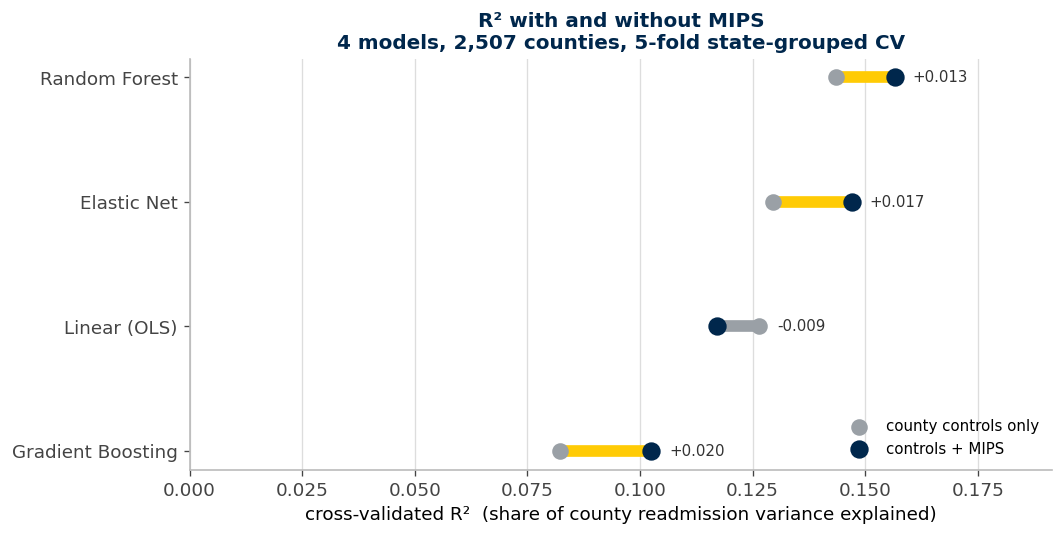

Figure 1 companion table:
shape: (4, 4)
┌───────────────────┬──────────────────┬──────────────┬────────┐
│ model             ┆ R2_controls_only ┆ R2_with_MIPS ┆ change │
│ ---               ┆ ---              ┆ ---          ┆ ---    │
│ str               ┆ f64              ┆ f64          ┆ f64    │
╞═══════════════════╪══════════════════╪══════════════╪════════╡
│ Random Forest     ┆ 0.143            ┆ 0.157        ┆ 0.013  │
│ Elastic Net       ┆ 0.13             ┆ 0.147        ┆ 0.017  │
│ Linear (OLS)      ┆ 0.126            ┆ 0.117        ┆ -0.009 │
│ Gradient Boosting ┆ 0.082            ┆ 0.102        ┆ 0.02   │
└───────────────────┴──────────────────┴──────────────┴────────┘


In [8]:
base = results.filter(pl.col("features") == "controls_only").drop("features")
full = results.filter(pl.col("features") == "controls_plus_mips").drop("features")
paired = []
for (tname, fs, m), scores in fold_scores.items():
    if fs != "controls_plus_mips" or m == "baseline_mean":
        continue
    d = scores - fold_scores[(tname, "controls_only", m)]
    paired.append({
        "target": tname, "model": m,
        "delta_r2_mean": d.mean(), "delta_r2_sd": d.std(),
        "folds_positive": int((d > 0).sum()),
    })
paired_tbl = pl.DataFrame(paired)

delta = (
    base.join(full, on=["target", "model"], suffix="_full")
    .join(paired_tbl, on=["target", "model"], how="left")
    .with_columns(
        delta_r2=pl.col("r2_mean_full") - pl.col("r2_mean"),
        delta_mae=pl.col("mae") - pl.col("mae_full"),
    )
    .select("target", "model", "r2_mean", "r2_mean_full", "delta_r2",
            "delta_r2_sd", "folds_positive", "delta_mae")
    .sort("target", "delta_r2", descending=[False, True])
)
with pl.Config(float_precision=4, tbl_cols=10):
    print(delta)
print("folds_positive = folds (of 5) where adding MIPS improved R2 on unseen states")

d = delta.filter(pl.col("target") == "readmission_pct").sort("r2_mean_full")
models = d["model"].to_list()
base = d["r2_mean"].to_numpy()
full = d["r2_mean_full"].to_numpy()
dl = d["delta_r2"].to_numpy()
ypos = np.arange(len(models))

fig, ax = plt.subplots(figsize=(9, 4.6))
for yi in ypos:
    seg = MAIZE if dl[yi] >= 0 else GRAY
    ax.plot([base[yi], full[yi]], [yi, yi], color=seg, linewidth=7, solid_capstyle="round", zorder=2)
    ax.text(max(base[yi], full[yi]) + 0.004, yi, f"{dl[yi]:+.3f}",
            va="center", ha="left", fontsize=9, color="#333333")
ax.scatter(base, ypos, color=GRAY, s=80, zorder=3, label="county controls only")
ax.scatter(full, ypos, color=BLUE, s=100, zorder=4, label="controls + MIPS")
ax.axvline(0, color="#cccccc", linewidth=1, zorder=1)
ax.set_yticks(ypos, [MODEL_NAMES.get(m, m) for m in models])
ax.set_xlim(0, max(full.max(), base.max()) + 0.035)
ax.set_xlabel("cross-validated R²  (share of county readmission variance explained)")
ax.set_title(f"R\u00b2 with and without MIPS\n"
             f"{len(MODEL_NAMES)} models, {len(y):,} counties, {N_SPLITS}-fold state-grouped CV",
             fontsize=12)
ax.legend(loc="lower right", fontsize=9, frameon=False)
clean_ax(ax, grid_axis="x")
fig.tight_layout()
fig.savefig(FIGURES / "sl_delta_r2.png")
fig.savefig(FIGURES / "sl_delta_r2.svg", metadata={"Date": None})
plt.show()

# Figure 1 companion table (report-ready)
fig1_table = (
    delta.filter(pl.col("target") == "readmission_pct")
    .sort("r2_mean_full", descending=True)
    .select(
        pl.col("model").replace(MODEL_NAMES).alias("model"),
        pl.col("r2_mean").round(3).alias("R2_controls_only"),
        pl.col("r2_mean_full").round(3).alias("R2_with_MIPS"),
        pl.col("delta_r2").round(3).alias("change"),
    )
)
print("Figure 1 companion table:")
print(fig1_table)


In [9]:
# two sensitivity checks that bound the headline
PRIMARY = "readmission_pct"

# 1) complete-controls subset: does the MIPS lift survive when no demographic control is imputed
comp = frame.filter(
    pl.col("BENE_RACE_WHT_PCT").is_not_null()
    & pl.col("BENE_DUAL_PCT").is_not_null()
    & pl.col("MA_PRTCPTN_RATE").is_not_null()
)
Xc = comp.select(FEATURE_SETS["controls_plus_mips"]).to_pandas()
yc = comp[TARGETS[PRIMARY]].to_numpy()
mask = ~np.isnan(yc)
Xc, yc = Xc[mask], yc[mask]
gc = comp["state"].to_numpy()[mask]
folds_c = list(GroupKFold(n_splits=N_SPLITS).split(Xc, yc, gc))
print(f"complete-controls subset: {len(yc):,} counties")
for m_name in ("elastic_net", "random_forest", "grad_boost"):
    r2 = {}
    for fs_name, feats in FEATURE_SETS.items():
        cv = cross_validate(make_pipe(MODELS[m_name]()), Xc[feats], yc, cv=folds_c, scoring={"r2": "r2"})
        r2[fs_name] = cv["test_r2"].mean()
    print(f"  {m_name:14} controls={r2['controls_only']:.4f}  +MIPS={r2['controls_plus_mips']:.4f}  delta={r2['controls_plus_mips'] - r2['controls_only']:+.4f}")

# 2) missingness ablation: replace MIPS values with their reporting indicators;
#    if indicators alone recover the lift, trees were reading who-reports, not how-well
sub_p, X_all_p, y_p, groups_p, folds_p = fold_info[PRIMARY]
indicators = X_all_p[final_measures].isna().astype(float)
indicators.columns = [f"{c}_missing" for c in final_measures]
X_ind = X_all_p[FEATURE_SETS["controls_only"]].join(indicators)
cv_ind = cross_validate(make_pipe(MODELS["grad_boost"]()), X_ind, y_p, cv=folds_p, scoring={"r2": "r2"})
r2_ctrl = fold_scores[(PRIMARY, "controls_only", "grad_boost")].mean()
r2_mips = fold_scores[(PRIMARY, "controls_plus_mips", "grad_boost")].mean()
print(f"\ngrad_boost R2: controls={r2_ctrl:.4f}  +MIPS values={r2_mips:.4f}  +missingness indicators only={cv_ind['test_r2'].mean():.4f}")
print("the indicator run sits close to the +MIPS run, so most of the gradient-boosting lift is which measures a county reports, not how well it scores")

complete-controls subset: 1,633 counties


  elastic_net    controls=0.1174  +MIPS=0.1343  delta=+0.0169


  random_forest  controls=0.1765  +MIPS=0.1925  delta=+0.0161


  grad_boost     controls=0.0866  +MIPS=0.1455  delta=+0.0589



grad_boost R2: controls=0.0823  +MIPS values=0.1024  +missingness indicators only=0.0987
the indicator run sits close to the +MIPS run, so most of the gradient-boosting lift is which measures a county reports, not how well it scores


In [10]:
# temporal robustness: the main analysis is same-year (PY2023 MIPS, 2023 outcomes),
# Which shows association but not temporal ordering. The geo file carries 2014-2024
# Outcomes with the same PY2023 MIPS join, so the same comparison runs with outcomes
# Measured BEFORE (2022) and AFTER (2024) the performance year:
#   - if the lift holds for 2024, performance precedes the outcome (stronger claim)
#   - if 2022 shows the same lift, the signal is a stable county trait, not an
#     effect of that year's performance (honest caveat for the report)
# Per the CMS Geographic Variation PUF methodology each YEAR is a single non-overlapping
# calendar year, so before/after is a genuine temporal split; the one caveat is that the
# 30-day readmission window creates a small boundary overlap at each year's edges.
X_2023 = frame.select(["county_fips"] + FEATURE_SETS["controls_plus_mips"])

for yr in ("2022", "2023", "2024"):
    yr_outcomes = (
        am.filter(pl.col("YEAR") == yr)
        .unique(subset=["county_fips"], keep="first")
        .select("county_fips", pl.col(TARGETS[PRIMARY]).cast(pl.Float64, strict=False).alias("y"))
    )
    panel = X_2023.join(yr_outcomes, on="county_fips", how="inner").drop_nulls("y").sort("county_fips")
    Xp = panel.select(FEATURE_SETS["controls_plus_mips"]).to_pandas()
    yp = panel["y"].to_numpy()
    gp = panel["county_fips"].str.slice(0, 2).to_numpy()
    folds_yr = list(GroupKFold(n_splits=N_SPLITS).split(Xp, yp, gp))
    r2 = {}
    for fs_name, feats in FEATURE_SETS.items():
        cv = cross_validate(make_pipe(MODELS["grad_boost"]()), Xp[feats], yp, cv=folds_yr, scoring={"r2": "r2"})
        r2[fs_name] = cv["test_r2"].mean()
    tag = {"2022": "outcomes BEFORE performance year", "2023": "same-year (main analysis)", "2024": "outcomes AFTER performance year"}[yr]
    print(f"{yr} ({tag}): n={len(yp):,}  controls={r2['controls_only']:.4f}  +MIPS={r2['controls_plus_mips']:.4f}  delta={r2['controls_plus_mips'] - r2['controls_only']:+.4f}")

2022 (outcomes BEFORE performance year): n=2,462  controls=0.1329  +MIPS=0.1757  delta=+0.0428


2023 (same-year (main analysis)): n=2,458  controls=0.0823  +MIPS=0.1024  delta=+0.0202


2024 (outcomes AFTER performance year): n=2,458  controls=0.0992  +MIPS=0.1186  delta=+0.0194


---
<a id="s8b"></a>

## **9. Does MIPS add anything beyond a county's own past readmissions?**

So far the small association holds up against demographic and specialty controls (and, in the extensions notebook, population weighting). The sharper question is whether MIPS tells us anything we would not already know from a county's own past. Because both MIPS quality and readmissions are sticky county traits, we add each county's **prior-year (2022) readmission rate** as a control and re-check the increment. Doing so mostly absorbs the association, which characterizes it as redundant with outcome history, not as spurious. We also report a formal confidence interval, because "positive in 5 of 5 folds" is a sign test on five points, not a significance test.

In [11]:
# prior-year (2022) readmission per county, from the same table (all years are loaded)
lag_col = TARGETS["readmission_pct"]
lag_2022 = (
    am.filter(pl.col("YEAR") == "2022")
    .unique(subset=["county_fips"], keep="first")
    .select("county_fips", pl.col(lag_col).cast(pl.Float64, strict=False).alias("readmit_2022"))
)
lag_frame = frame.join(lag_2022, on="county_fips", how="left")
lsub = (lag_frame
        .filter(pl.col(lag_col).is_not_null() & pl.col("readmit_2022").is_not_null())
        .sort("county_fips"))
ly = lsub[lag_col].to_numpy()
lfolds = list(GroupKFold(n_splits=N_SPLITS).split(
    lsub.select(FEATURE_SETS["controls_plus_mips"]).to_pandas(), ly, lsub["state"].to_numpy()))

def en_r2(cols):
    X = lsub.select(cols).to_pandas()
    return cross_validate(make_pipe(MODELS["elastic_net"]()), X, ly, cv=lfolds, scoring={"r2": "r2"})["test_r2"].mean()

ctrl = FEATURE_SETS["controls_only"]
r2_ctrl = en_r2(ctrl)
r2_mips = en_r2(FEATURE_SETS["controls_plus_mips"])
r2_lag = en_r2(ctrl + ["readmit_2022"])
r2_lag_mips = en_r2(ctrl + ["readmit_2022"] + final_measures)
mips_alone = r2_mips - r2_ctrl
lag_alone = r2_lag - r2_ctrl
mips_after_lag = r2_lag_mips - r2_lag
print(f"n = {len(ly):,} counties with a prior-year readmission rate")
print(f"controls only                  R2 = {r2_ctrl:.4f}")
print(f"controls + MIPS                R2 = {r2_mips:.4f}   (MIPS alone adds {mips_alone:+.4f})")
print(f"controls + prior-year readmit  R2 = {r2_lag:.4f}   (prior year alone adds {lag_alone:+.4f})")
print(f"controls + prior-year + MIPS   R2 = {r2_lag_mips:.4f}")
print(f"MIPS increment beyond outcome history (with prior-year control): {mips_after_lag:+.4f}")
print(f"outcome history alone contains ~{lag_alone/max(mips_alone,1e-6):.0f}x the county-level information MIPS adds")

n = 2,444 counties with a prior-year readmission rate
controls only                  R2 = 0.1139
controls + MIPS                R2 = 0.1203   (MIPS alone adds +0.0064)
controls + prior-year readmit  R2 = 0.3410   (prior year alone adds +0.2271)
controls + prior-year + MIPS   R2 = 0.3433
MIPS increment beyond outcome history (with prior-year control): +0.0023
outcome history alone contains ~35x the county-level information MIPS adds


In [12]:
from scipy import stats

sub9, X9, y9, g9, folds9 = fold_info["readmission_pct"]
en_c = cross_validate(make_pipe(MODELS["elastic_net"]()), X9[FEATURE_SETS["controls_only"]], y9,
                      cv=folds9, scoring={"r2": "r2"})["test_r2"]
en_f = cross_validate(make_pipe(MODELS["elastic_net"]()), X9[FEATURE_SETS["controls_plus_mips"]], y9,
                      cv=folds9, scoring={"r2": "r2"})["test_r2"]
d = en_f - en_c
t_stat, p_val = stats.ttest_rel(en_f, en_c)
tcrit = stats.t.ppf(0.975, len(d) - 1)
half = tcrit * d.std(ddof=1) / np.sqrt(len(d))
full_r2 = en_f.mean()
print(f"Elastic Net incremental R2: {d.mean():+.4f}  95% CI [{d.mean()-half:+.4f}, {d.mean()+half:+.4f}]")
print(f"paired t({len(d)-1}) = {t_stat:.2f}, p = {p_val:.3f}   (the 5/5-fold sign test alone is one-sided p = 0.031)")
print(f"in variance terms: the increment is {d.mean()*100:.1f}% of total readmission variance,")
print(f"and the full model still leaves {(1-full_r2)*100:.0f}% of county readmission variance unexplained")

Elastic Net incremental R2: +0.0174  95% CI [-0.0000, +0.0349]
paired t(4) = 2.78, p = 0.050   (the 5/5-fold sign test alone is one-sided p = 0.031)
in variance terms: the increment is 1.7% of total readmission variance,
and the full model still leaves 85% of county readmission variance unexplained


---
<a id="s9"></a>

## **10. Explanatory model: which measures matter**

Inference fit on the full panel: statsmodels OLS with **cluster robust errors by state** (the
residual maps in section 11 show state level pooling, so plain robust errors would overstate
precision). Each measure is fitted in **its own model**, controls plus that one measure, rather than
all 49 at once. A cluster robust covariance has rank at most the number of clusters, so an
all-measures fit (61 parameters against 51 states) is rank deficient and its standard errors are
biased downward; one model per measure is 13 parameters against 51 states. No joint block test is
reported, because it is uninterpretable for the same reason. Note the estimand this implies: each
coefficient is the association net of demographics and specialty, **not** the increment over the
other 48 correlated measures.

Two screens govern the table. Features are standardized on observed values only, then missing cells
enter at the standardized center, so a measure reported by few groups is mostly imputed and its
collapsed variance would shrink its standard error and manufacture significance. A **70% coverage
floor** therefore governs what is reported: all 49 measures are fitted, but only the 16 carrying a
genuine reported value for at least 70% of counties are FDR corrected and read. Coverage depends on
who reported and never on the outcome, so screening on it is a data quality rule rather than selection
on results, and every measure including the excluded ones is written with its coefficient, p value and
coverage to `coef_table_2023_all_measures.csv`. **BH FDR q values** correct across the 16.

Coefficients are sign adjusted to read "effect of 1 SD better performance." Elastic Net shares
this same imputed linear design and fits all 49 measures jointly, so it is a stability check on a
different estimand rather than an independent view; the
tree based permutation importance (scored on held out states) is the one genuinely independent
opinion. Given the weak overall signal (section 9), read agreement across the three as which measures are least unstable, not as confirmation of an effect.

OLS in-sample R2 (not comparable to CV scores): controls=0.1922  controls+MIPS=0.2425
cluster-robust identification: per-measure model has 13 parameters vs 51 state clusters (the all-measures model had 61, above the rank ceiling, so it is used only for the R2 reference above)
coverage floor 70%: 16 of 49 measures eligible (33 excluded as mostly imputed)
3 of 16 eligible measures survive BH-FDR at q < 0.05
shape: (12, 8)
┌─────────────────────┬─────────┬─────────┬─────────┬────────┬─────────────┬──────────────┬────────┐
│ feature             ┆ coef    ┆ ci_low  ┆ ci_high ┆ p      ┆ pct_imputed ┆ pct_observed ┆ q      │
│ ---                 ┆ ---     ┆ ---     ┆ ---     ┆ ---    ┆ ---         ┆ ---          ┆ ---    │
│ str                 ┆ f64     ┆ f64     ┆ f64     ┆ f64    ┆ f64         ┆ f64          ┆ f64    │
╞═════════════════════╪═════════╪═════════╪═════════╪════════╪═════════════╪══════════════╪════════╡
│ MIPS_GRP_001_overal ┆ -0.0029 ┆ -0.0045 ┆ -0.0012 ┆ 0.0005 ┆ 8.6000  

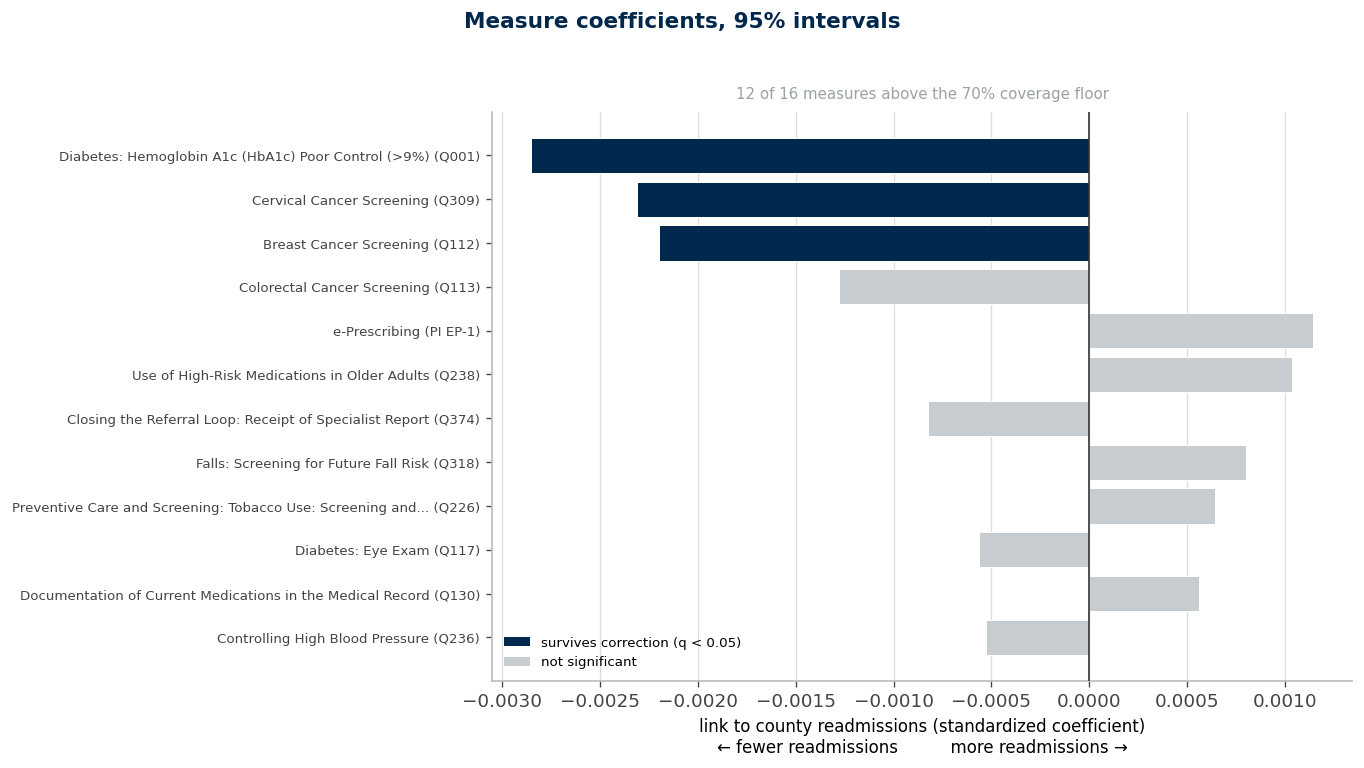

Figure 2 companion table (survive FDR, q < 0.05):
shape: (3, 5)
┌─────────────────────────────────────────────────────┬─────────┬─────────┬─────────┬────────┐
│ measure                                             ┆ coef    ┆ ci_low  ┆ ci_high ┆ q      │
│ ---                                                 ┆ ---     ┆ ---     ┆ ---     ┆ ---    │
│ str                                                 ┆ f64     ┆ f64     ┆ f64     ┆ f64    │
╞═════════════════════════════════════════════════════╪═════════╪═════════╪═════════╪════════╡
│ Diabetes: Hemoglobin A1c (HbA1c) Poor Control (>9%) ┆ -0.0029 ┆ -0.0045 ┆ -0.0012 ┆ 0.0069 │
│ (Q001)                                              ┆         ┆         ┆         ┆        │
│ Cervical Cancer Screening (Q309)                    ┆ -0.0023 ┆ -0.0037 ┆ -0.001  ┆ 0.0069 │
│ Breast Cancer Screening (Q112)                      ┆ -0.0022 ┆ -0.0038 ┆ -0.0006 ┆ 0.0374 │
└─────────────────────────────────────────────────────┴─────────┴─────────┴──────

In [13]:
# Statistical Inference
import statsmodels.api as sm

def standardized_design(X_pd, feats, flip=None):
    """Standardize features for the explanatory OLS fit.

    Uses the same imputation as the predictive pipeline (median-impute, then
    standardize) so the inference and prediction models see identical data.

    Args:
        X_pd: Feature DataFrame, may contain missing values.
        feats: Column names to include, in order.
        flip: Optional map of column name to sign. Columns mapped to a
            negative sign are inverted so higher always means better.

    Returns:
        Standardized DataFrame with no missing values.
    """
    Z = X_pd[feats].copy()
    Z = Z.fillna(Z.median(numeric_only=True))
    Z = (Z - Z.mean()) / Z.std(ddof=0)
    if flip:
        for c, s in flip.items():
            if c in Z.columns and s < 0:
                Z[c] = -Z[c]
    return Z

PRIMARY = "readmission_pct"
sub, X_all, y, groups, folds = fold_info[PRIMARY]

# Explanatory fit on the full panel; predictive claims stay with the grouped CV above
Z_ctrl = standardized_design(X_all, FEATURE_SETS["controls_only"])
Z_full = standardized_design(X_all, FEATURE_SETS["controls_plus_mips"], flip=flip_sign)

cluster_groups = sub["state"].to_numpy()
ols_ctrl = sm.OLS(y, sm.add_constant(Z_ctrl)).fit(cov_type="cluster", cov_kwds={"groups": cluster_groups})
ols_full = sm.OLS(y, sm.add_constant(Z_full)).fit(cov_type="cluster", cov_kwds={"groups": cluster_groups})
print(f"OLS in-sample R2 (not comparable to CV scores): controls={ols_ctrl.rsquared:.4f}  controls+MIPS={ols_full.rsquared:.4f}")

# Per-measure inference is NOT read off ols_full. That model carries one parameter
# per measure plus controls, which exceeds the number of state clusters, and a
# cluster-robust covariance has rank at most G (the cluster count). Above that
# threshold its standard errors are biased downward and a joint Wald test across
# all measures is uninterpretable, so neither is reported.
#
# Each measure is instead tested in its own model: the same controls plus that one
# measure, well under the 51-cluster ceiling. BH-FDR then corrects across the tests.
from statsmodels.stats.multitest import multipletests

CTRL_FEATS = FEATURE_SETS["controls_only"]
n_clusters = len(np.unique(cluster_groups))
print(f"cluster-robust identification: per-measure model has {len(CTRL_FEATS) + 2} parameters "
      f"vs {n_clusters} state clusters (the all-measures model had {len(ols_full.params)}, "
      f"above the rank ceiling, so it is used only for the R2 reference above)")

rows = []
for m in final_measures:
    Zm = standardized_design(X_all, CTRL_FEATS + [m], flip=flip_sign)
    fit_m = sm.OLS(y, sm.add_constant(Zm)).fit(
        cov_type="cluster", cov_kwds={"groups": cluster_groups})
    ci_m = fit_m.conf_int()
    rows.append({
        "feature": m,
        "coef": float(fit_m.params[m]),
        "ci_low": float(ci_m[0][m]),
        "ci_high": float(ci_m[1][m]),
        "p": float(fit_m.pvalues[m]),
        "pct_imputed": round(float(X_all[m].isna().mean()) * 100, 1),
    })

# Coverage floor. A measure reported by few groups is mostly median-imputed, and
# imputing then treating the fill as observed collapses that column's variance, which
# shrinks its standard error and manufactures significance. Coverage depends only on
# who reported, never on the outcome, so screening on it before testing is a data
# quality rule rather than selection on results.
COVERAGE_FLOOR = 70.0   # percent of counties carrying a genuine reported value

full_tbl = (
    pl.DataFrame(rows)
    .with_columns(pct_observed=(100.0 - pl.col("pct_imputed")).round(1))
    .sort(pl.col("coef").abs(), descending=True)
)
coef_tbl = full_tbl.filter(pl.col("pct_observed") >= COVERAGE_FLOOR)
print(f"coverage floor {COVERAGE_FLOOR:.0f}%: {coef_tbl.height} of {full_tbl.height} measures eligible "
      f"({full_tbl.height - coef_tbl.height} excluded as mostly imputed)")

# Multiplicity: one test per eligible measure, so read q (BH-FDR), not raw p
q = multipletests(coef_tbl["p"].to_numpy(), method="fdr_bh")[1]
coef_tbl = coef_tbl.with_columns(q=pl.Series(q))
print(f"{int((coef_tbl['q'] < 0.05).sum())} of {coef_tbl.height} eligible measures survive BH-FDR at q < 0.05")

# Full table including the excluded measures, so the screen is auditable
full_tbl.write_csv(DATA / "interim" / "coef_table_2023_all_measures.csv")
with pl.Config(tbl_rows=12, float_precision=4):
    print(coef_tbl.head(12))

top = coef_tbl.head(12).reverse()
ci_low = top["ci_low"].to_numpy()
ci_high = top["ci_high"].to_numpy()
coef = top["coef"].to_numpy()
qval = top["q"].to_numpy()
sig = qval < 0.05
ypos = np.arange(top.height)

# Readable measure names: measure_cd -> title, taken from the modeling data itself
measure_titles = dict(am.select("measure_cd", "measure_title").unique().iter_rows())

def measure_label(code):
    """Turn a code like MIPS_GRP_065_overall into 'Readable name (Q065)'."""
    title = measure_titles.get(code, code)
    parts = code.split("_")
    if code.startswith("MIPS_GRP_"):
        sid = "Q" + parts[2]
    elif code.startswith("PI_GRP_"):
        sid = "PI " + "-".join(parts[2:])
    elif code.startswith("IA_GRP_"):
        sid = "IA " + "-".join(parts[2:])
    elif code.startswith("QCDR_GRP_"):
        sid = "QCDR " + parts[2]
    else:
        sid = code
    if len(title) > 62:
        title = title[:62].rsplit(" ", 1)[0] + "..."
    return f"{title} ({sid})"

ylabels = [measure_label(c) for c in top["feature"].to_list()]
coef_tbl.with_columns(
    measure_title=pl.col("feature").replace_strict(measure_titles, default=None)
).write_csv(DATA / "interim" / "coef_table_2023.csv")  # titles included so 05 can label without reloading am

from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(11.5, 6.5))
colors = [BLUE if sig[i] else "#c7ccd1" for i in range(top.height)]
ax.barh(ypos, coef, color=colors, edgecolor="white", linewidth=0.6, zorder=3)
ax.axvline(0, color="#333333", linewidth=1, zorder=4)
ax.set_yticks(ypos, ylabels, fontsize=8)
ax.set_xlabel("link to county readmissions (standardized coefficient)\n"
              "← fewer readmissions          more readmissions →", fontsize=10)
ax.set_title(f"{top.height} of {coef_tbl.height} measures above the {COVERAGE_FLOOR:.0f}% coverage floor",
             fontsize=9, fontweight="normal", color=GRAY, pad=8)
fig.suptitle("Measure coefficients, 95% intervals",
             fontsize=13, fontweight="bold", color=BLUE, y=0.98)
ax.legend(handles=[Patch(facecolor=BLUE, label="survives correction (q < 0.05)"),
                   Patch(facecolor="#c7ccd1", label="not significant")],
          loc="lower left", fontsize=8, frameon=False)
clean_ax(ax, grid_axis="x")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIGURES / "sl_top_measures_ci.png")
fig.savefig(FIGURES / "sl_top_measures_ci.svg", metadata={"Date": None})
plt.show()

# Figure 2 companion table: measures surviving FDR correction
fig2_table = (
    coef_tbl.filter(pl.col("q") < 0.05)
    .select(
        pl.col("feature").map_elements(measure_label, return_dtype=pl.String).alias("measure"),
        pl.col("coef").round(4).alias("coef"),
        pl.col("ci_low").round(4).alias("ci_low"),
        pl.col("ci_high").round(4).alias("ci_high"),
        pl.col("q").round(4).alias("q"),
    )
)
print("Figure 2 companion table (survive FDR, q < 0.05):")
with pl.Config(fmt_str_lengths=90, tbl_rows=12):
    print(fig2_table)


In [14]:
X_full_pd = X_all[FEATURE_SETS["controls_plus_mips"]]

en_pipe = make_pipe(MODELS["elastic_net"]())
en_pipe.fit(X_full_pd, y)
en_coefs = en_pipe.named_steps["model"].coef_
en_tbl = (
    pl.DataFrame({"feature": list(X_full_pd.columns), "coef_raw": en_coefs})
    .filter(pl.col("feature").is_in(final_measures) & (pl.col("coef_raw").abs() > 1e-10))
    .with_columns(
        coef=pl.col("coef_raw") * pl.col("feature").map_elements(lambda c: flip_sign.get(c, 1.0), return_dtype=pl.Float64)
    )
    .sort(pl.col("coef").abs(), descending=True)
    .select("feature", "coef")
)
print(f"Elastic Net keeps {en_tbl.height} of {len(final_measures)} measures (rest shrunk to zero)")
with pl.Config(tbl_rows=12, float_precision=4):
    print(en_tbl.head(12))

Elastic Net keeps 25 of 49 measures (rest shrunk to zero)
shape: (12, 2)
┌──────────────────────┬─────────┐
│ feature              ┆ coef    │
│ ---                  ┆ ---     │
│ str                  ┆ f64     │
╞══════════════════════╪═════════╡
│ MIPS_GRP_001_overall ┆ -0.0021 │
│ MIPS_GRP_065_overall ┆ -0.0021 │
│ MIPS_GRP_309_overall ┆ -0.0015 │
│ MIPS_GRP_126_overall ┆ -0.0010 │
│ MIPS_GRP_475_overall ┆ 0.0010  │
│ MIPS_GRP_112_overall ┆ -0.0009 │
│ MIPS_GRP_318_overall ┆ 0.0009  │
│ MIPS_GRP_310_overall ┆ 0.0009  │
│ PI_GRP_HIE_1         ┆ 0.0008  │
│ PI_GRP_EP_1          ┆ 0.0006  │
│ PI_GRP_HIE_4         ┆ 0.0006  │
│ MIPS_GRP_047_overall ┆ 0.0005  │
└──────────────────────┴─────────┘


In [15]:
from sklearn.inspection import permutation_importance

imp_acc = np.zeros(len(X_full_pd.columns))
gb_pipe = make_pipe(MODELS["grad_boost"]())
for tr, te in folds:
    gb_pipe.fit(X_full_pd.iloc[tr], y[tr])
    pi = permutation_importance(gb_pipe, X_full_pd.iloc[te], y[te],
                                n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
    imp_acc += pi.importances_mean
imp_acc /= len(folds)

imp_tbl = (
    pl.DataFrame({"feature": list(X_full_pd.columns), "importance": imp_acc})
    .filter(pl.col("feature").is_in(final_measures))
    .sort("importance", descending=True)
)
with pl.Config(tbl_rows=10, float_precision=5):
    print(imp_tbl.head(10))

TOP_N = 10
ols_top = set(coef_tbl.head(TOP_N)["feature"].to_list())
en_top = set(en_tbl.head(TOP_N)["feature"].to_list())
gb_top = set(imp_tbl.head(TOP_N)["feature"].to_list())
agree = (
    pl.DataFrame({"feature": sorted(ols_top | en_top | gb_top)})
    .with_columns(
        ols=pl.col("feature").is_in(list(ols_top)),
        elastic_net=pl.col("feature").is_in(list(en_top)),
        grad_boost=pl.col("feature").is_in(list(gb_top)),
    )
    .with_columns(votes=pl.col("ols").cast(pl.Int8) + pl.col("elastic_net").cast(pl.Int8) + pl.col("grad_boost").cast(pl.Int8))
    .sort("votes", descending=True)
)
print("\ncross-method agreement (top 10 lists):")
with pl.Config(tbl_rows=15):
    print(agree.filter(pl.col("votes") >= 2))

shape: (10, 2)
┌──────────────────────┬────────────┐
│ feature              ┆ importance │
│ ---                  ┆ ---        │
│ str                  ┆ f64        │
╞══════════════════════╪════════════╡
│ MIPS_GRP_001_overall ┆ 0.02387    │
│ MIPS_GRP_226_overall ┆ 0.00751    │
│ MIPS_GRP_130_overall ┆ 0.00715    │
│ PI_GRP_PEA_1         ┆ 0.00611    │
│ MIPS_GRP_309_overall ┆ 0.00604    │
│ MIPS_GRP_112_overall ┆ 0.00586    │
│ MIPS_GRP_047_overall ┆ 0.00516    │
│ MIPS_GRP_126_overall ┆ 0.00508    │
│ MIPS_GRP_438_overall ┆ 0.00437    │
│ MIPS_GRP_318_overall ┆ 0.00322    │
└──────────────────────┴────────────┘

cross-method agreement (top 10 lists):
shape: (7, 5)
┌──────────────────────┬───────┬─────────────┬────────────┬───────┐
│ feature              ┆ ols   ┆ elastic_net ┆ grad_boost ┆ votes │
│ ---                  ┆ ---   ┆ ---         ┆ ---        ┆ ---   │
│ str                  ┆ bool  ┆ bool        ┆ bool       ┆ i8    │
╞══════════════════════╪═══════╪═════════════╪═════

These rankings describe the small cross-sectional association, which section 9 shows is
essentially absorbed by outcome history, so read them as characterization, not as drivers. The measures that
rank (HbA1c control, cervical and breast cancer screening) are clinically plausible primary care and
preventive processes, so the association is concentrated in primary care. After BH FDR across the 16
measures clearing the coverage floor, three survive: HbA1c poor control (001, q = 0.0069), cervical
cancer screening (309, q = 0.0069), and breast cancer screening (112, q = 0.0374). All three point the
same way, better performance associating with fewer readmissions, and all three rest on 78% to 91%
observed data. Two measures that cleared FDR under the earlier all-measures fit do not appear here, both
excluded on coverage rather than on significance: URI stewardship (065) falls just under the floor at
69.1% observed, and HIV screening (475), which carried the counterintuitive positive sign, falls well
below it at 55.9%. Fitted in its own model, 475 is also indistinguishable from zero (p = 0.91). The surviving set is small and uniform in direction, which is more consistent with a modest
shared primary care signal than with a coherent causal driver, and section 9 already shows it is
essentially absorbed by outcome history.

The same primary care measures also top the unsupervised PC1, so the supervised and unsupervised views
identify the same cross-sectional structure. Treat this as a shared characterization rather than
independent corroboration of an effect, since that clustering had near-zero separation
(silhouette ~0.10).

---
<a id="s10"></a>

## **11. Cluster tie in and residual checks**

Two diagnostics: do prediction errors differ across the unsupervised county clusters, and do
residuals pool by state (a cheap spatial autocorrelation signal; Moran's I below quantifies it).

Note: the cluster file's `county_fips` lost its leading zeros upstream, so it is re-padded here.

The cluster labels apply the unsupervised notebook's stricter coverage filters (1,400 counties) rather than this notebook's 2,507, so the residual-by-cluster comparison below covers only the 1,393 counties present in both.

The clusters come from the unsupervised notebook (K-means, k=2, on a PCA of county MIPS profiles). Its first component is preventive-care performance, so the split is along that axis: **cluster 0** is the lower-preventive-care group (~445 counties; breast-cancer screening averages ~44%, cervical ~30%) and **cluster 1** is the higher-preventive-care group (~955 counties; ~64% and ~47%). The separation is weak (silhouette 0.096, a continuum rather than distinct types), and the two clusters have nearly identical readmission rates, so similar residuals across them is expected.

best MIPS-lift model for readmission_pct: grad_boost



residuals by unsupervised cluster:
shape: (2, 4)
┌─────────┬─────┬────────────┬─────────┐
│ cluster ┆ n   ┆ mean_resid ┆ mae     │
│ ---     ┆ --- ┆ ---        ┆ ---     │
│ str     ┆ u32 ┆ f64        ┆ f64     │
╞═════════╪═════╪════════════╪═════════╡
│ 0       ┆ 444 ┆ -0.00039   ┆ 0.01806 │
│ 1       ┆ 949 ┆ -0.00055   ┆ 0.01628 │
└─────────┴─────┴────────────┴─────────┘

states with largest mean residuals (spatial pooling check):
shape: (6, 3)
┌───────┬────────────┬─────┐
│ state ┆ mean_resid ┆ n   │
│ ---   ┆ ---        ┆ --- │
│ str   ┆ f64        ┆ u32 │
╞═══════╪════════════╪═════╡
│ 49    ┆ -0.03095   ┆ 20  │
│ 08    ┆ -0.02486   ┆ 48  │
│ 16    ┆ -0.02154   ┆ 29  │
│ 17    ┆ 0.01590    ┆ 84  │
│ 24    ┆ 0.01711    ┆ 24  │
│ 54    ┆ 0.01840    ┆ 36  │
└───────┴────────────┴─────┘


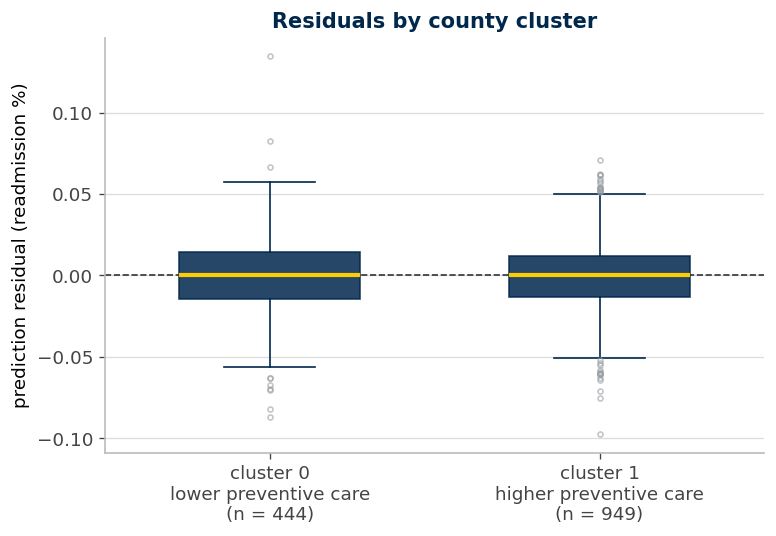

In [16]:
# cluster labels from the 03_unsupervised_learning notebook; that export lost
# The FIPS leading zeros, so they are re-padded before joining
clusters = (
    pl.read_csv(DATA / "processed" / "county_clusters.csv", infer_schema_length=0)
    .with_columns(pl.col("county_fips").str.zfill(5))
    .select("county_fips", "cluster")
)
assert clusters["county_fips"].str.len_chars().min() == 5

best_model = delta.filter(pl.col("target") == PRIMARY).sort("delta_r2", descending=True)["model"][0]
print(f"best MIPS-lift model for {PRIMARY}: {best_model}")

pred = cross_val_predict(make_pipe(MODELS[best_model]()), X_full_pd, y, cv=folds)
resid_df = (
    sub.select("county_fips", "state")
    .with_columns(resid=pl.Series(y - pred))
    .join(clusters, on="county_fips", how="left")
)

by_cluster = resid_df.drop_nulls("cluster").group_by("cluster").agg(
    n=pl.len(),
    mean_resid=pl.col("resid").mean(),
    mae=pl.col("resid").abs().mean(),
).sort("cluster")
print("\nresiduals by unsupervised cluster:")
with pl.Config(float_precision=5):
    print(by_cluster)

by_state = resid_df.group_by("state").agg(mean_resid=pl.col("resid").mean(), n=pl.len())
ext = by_state.sort("mean_resid")
print("\nstates with largest mean residuals (spatial pooling check):")
with pl.Config(float_precision=5):
    print(pl.concat([ext.head(3), ext.tail(3)]))

labels_c = sorted(resid_df.drop_nulls("cluster")["cluster"].unique().to_list())
groups_plot = [resid_df.filter(pl.col("cluster") == c)["resid"].to_list() for c in labels_c]
counts = [len(g) for g in groups_plot]
cluster_desc = {"0": "lower preventive care", "1": "higher preventive care"}  # notebook 03 PC1 (pinned labels)

# save residuals for the standalone interactive county map
(resid_df.select("county_fips", "resid", "cluster")
 .write_csv(DATA / "interim" / "residuals_2023.csv"))

fig, ax = plt.subplots(figsize=(6.6, 4.6))
bp = ax.boxplot(groups_plot, widths=0.55,
                tick_labels=[f"cluster {c}\n{cluster_desc.get(str(c), '')}\n(n = {n:,})" for c, n in zip(labels_c, counts)],
                patch_artist=True,
                flierprops=dict(marker="o", markersize=3, markerfacecolor="none",
                                markeredgecolor=GRAY, alpha=0.6))
for patch in bp["boxes"]:
    patch.set_facecolor(BLUE); patch.set_alpha(0.85); patch.set_edgecolor(BLUE)
for line in bp["medians"]:
    line.set_color(MAIZE); line.set_linewidth(2.5)
for el in ("whiskers", "caps"):
    for line in bp[el]:
        line.set_color(BLUE)
ax.axhline(0, color="#333333", linewidth=1, linestyle="--")
ax.set_ylabel("prediction residual (readmission %)")
ax.set_title("Residuals by county cluster", fontsize=12.5)
clean_ax(ax, grid_axis="y")
fig.tight_layout()
fig.savefig(FIGURES / "sl_residuals_cluster.png")
fig.savefig(FIGURES / "sl_residuals_cluster.svg", metadata={"Date": None})
plt.show()


### **11.1 Residual choropleth**

Where does the model miss on the map? This shades each modeled county by its readmission
residual (actual minus predicted): **maize** counties are under-predicted (real rate higher than
the model expects), **blue** counties are over-predicted. Counties outside the modeling panel are
light gray. Structure in the colors (regional clumping) is the visual companion to the state
residual pooling above. Contiguous US only; Alaska, Hawaii, and territories are omitted for a
single clean panel.

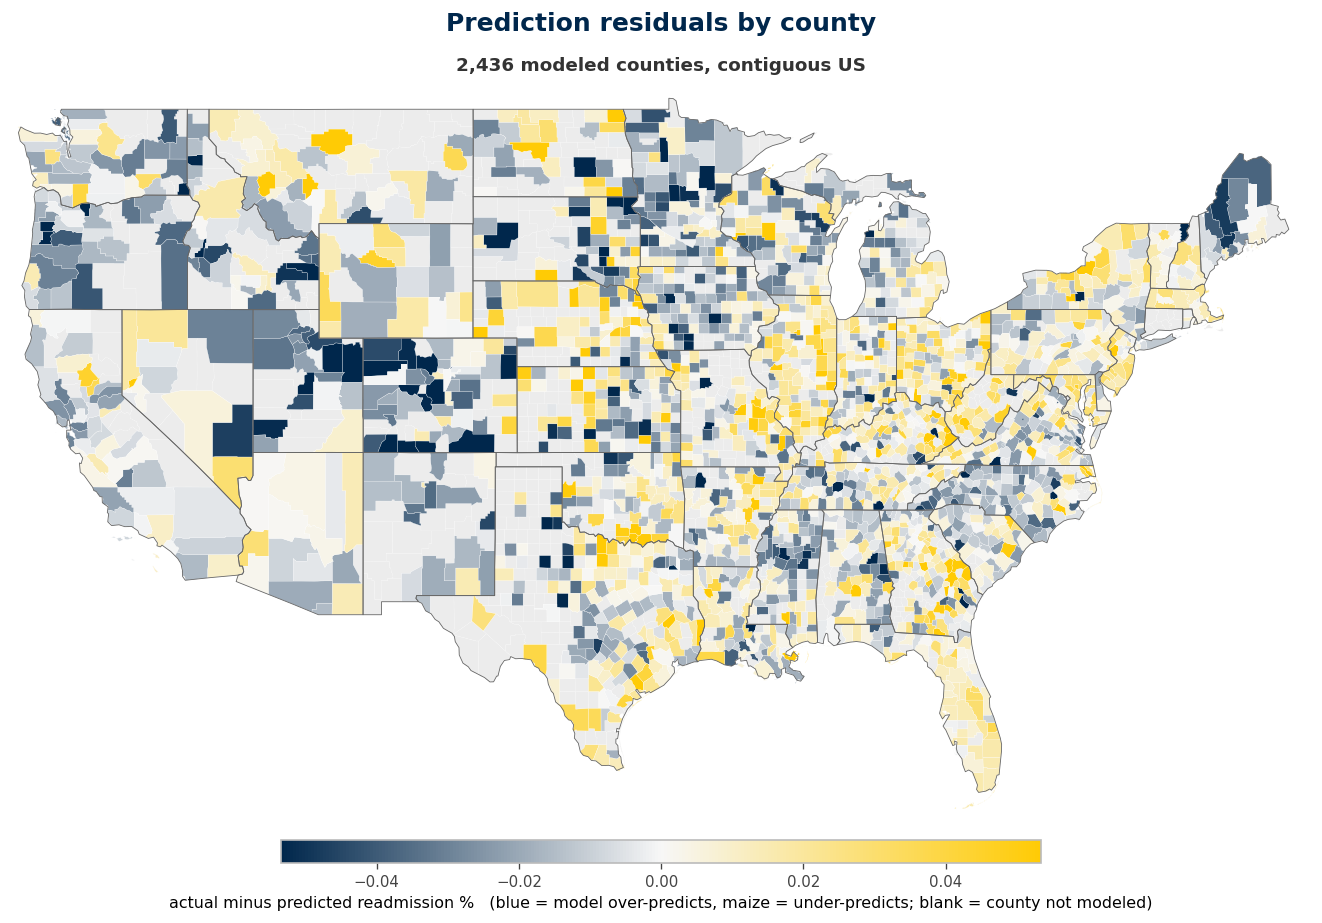

In [17]:
import json
import urllib.request
from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# Choropleth is hand-rolled with matplotlib PolyCollection rather than a geo library,
# which keeps the dependency list to what requirements.txt already pins (no geopandas
# or plotly runtime dependency).
#
# County geometry source: plotly/datasets geojson-counties-fips.json (MIT licensed
# repository; the boundaries themselves are US Census derived, public domain).
# Fetched once into data/raw (gitignored), then loaded locally.
GEO_PATH = DATA / "raw" / "geojson-counties-fips.json"
GEO_URL = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
if not GEO_PATH.exists():
    urllib.request.urlretrieve(GEO_URL, GEO_PATH)
counties_geo = json.loads(GEO_PATH.read_text())


def county_rings(geometry):
    """Yield each polygon's exterior ring as a list of (lon, lat) points.

    Args:
        geometry: A GeoJSON Polygon or MultiPolygon geometry dict.

    Returns:
        Generator of exterior rings; MultiPolygon yields one ring per part.
    """
    if geometry["type"] == "Polygon":
        yield geometry["coordinates"][0]
    elif geometry["type"] == "MultiPolygon":
        for part in geometry["coordinates"]:
            yield part[0]


# Residual lookup: actual minus predicted, from the best-model CV predictions above
resid_lookup = dict(resid_df.select("county_fips", "resid").iter_rows())

# Blue (over-predict) to white to maize (under-predict), on brand and readable
diverging = LinearSegmentedColormap.from_list("blue_maize", [BLUE, "#f7f7f7", MAIZE])
lim = float(np.nanpercentile(np.abs(list(resid_lookup.values())), 95))
norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)

# Territories and non-contiguous states omitted for a single clean panel
DROP_STATES = {"02", "15", "60", "66", "69", "72", "78"}

modeled_polys, modeled_vals, context_polys = [], [], []
modeled_fips = set()
for feature in counties_geo["features"]:
    fips = feature["id"]
    if fips[:2] in DROP_STATES:
        continue
    for ring in county_rings(feature["geometry"]):
        if fips in resid_lookup:
            modeled_polys.append(ring)
            modeled_vals.append(resid_lookup[fips])
            modeled_fips.add(fips)
        else:
            context_polys.append(ring)

fig, ax = plt.subplots(figsize=(13, 7.8))
ax.add_collection(PolyCollection(context_polys, facecolors="#ececec", edgecolors="white", linewidths=0.1))
modeled = PolyCollection(modeled_polys, edgecolors="white", linewidths=0.15, cmap=diverging, norm=norm)
modeled.set_array(np.array(modeled_vals))
ax.add_collection(modeled)

# State boundaries for geographic orientation. This file is committed to data/raw
# (small, static reference geometry). The overlay is decorative, so a missing file
# degrades the basemap rather than stopping the notebook and everything after it.
# Source: Leaflet choropleth example us-states.geojson, US Census derived boundaries.
STATES_PATH = DATA / "raw" / "us-states.geojson"
try:
    states_geo = json.loads(STATES_PATH.read_text())
    state_rings = [ring for feat in states_geo["features"]
                   if feat["properties"]["name"] not in {"Alaska", "Hawaii", "Puerto Rico"}
                   for ring in county_rings(feat["geometry"])]
    ax.add_collection(PolyCollection(state_rings, facecolors="none", edgecolors="#666666",
                                     linewidths=0.5, zorder=5))
except FileNotFoundError:
    print(f"note: {STATES_PATH.name} not found, drawing without the state overlay")

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_aspect(1.3)
ax.axis("off")
ax.set_title(f"{len(modeled_fips):,} modeled counties, contiguous US",
             color="#333333", fontsize=11, pad=6)
fig.suptitle("Prediction residuals by county",
             color=BLUE, fontsize=15, fontweight="bold", y=0.98)

cbar = fig.colorbar(modeled, ax=ax, orientation="horizontal",
                    fraction=0.04, pad=0.02, shrink=0.5, aspect=34)
cbar.set_label("actual minus predicted readmission %   "
               "(blue = model over-predicts, maize = under-predicts; blank = county not modeled)",
               fontsize=9.5)
cbar.ax.tick_params(labelsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "sl_residual_choropleth.png")
plt.show()


### **11.2 Spatial autocorrelation (Moran's I)**

The residual map hints at regional structure; Moran's I quantifies it. County centroids come from
the same geojson, spatial neighbors are the 8 nearest counties (row standardized), and significance
is a 999 permutation test (numpy only, no spatial stats dependency). We report I for the raw
outcome and for the model residuals: if the model plus state grouped controls absorbed the spatial
signal, residual I should be far smaller than raw outcome I.

In [18]:
from sklearn.neighbors import NearestNeighbors

def morans_i(values, neighbor_idx):
    """Global Moran's I with row-standardized k-nearest-neighbor weights.

    Args:
        values: 1-D array of the variable, aligned to neighbor_idx rows.
        neighbor_idx: (n, k) integer array of each unit's k nearest neighbors.

    Returns:
        Moran's I statistic (float). Row-standardized weights make S0 = n, so
        I reduces to the correlation between each value and its neighbor mean.
    """
    z = values - values.mean()
    lag = z[neighbor_idx].mean(axis=1)
    return float((z * lag).sum() / (z ** 2).sum())

# Align residuals + raw outcome to counties that have geometry
raw_out = sub.select("county_fips", pl.col(TARGETS[PRIMARY]).cast(pl.Float64).alias("y"))
spatial = resid_df.drop_nulls("resid").join(raw_out, on="county_fips", how="inner")
cent = {}
for feature in counties_geo["features"]:
    if feature["id"] in set(spatial["county_fips"].to_list()):
        pts = max(county_rings(feature["geometry"]), key=len)
        cent[feature["id"]] = np.asarray(pts).mean(axis=0)

# restrict to the contiguous US (drop AK, HI, territories) and correct the
# lon/lat distortion by scaling longitude by cos(mean latitude) before KNN
DROP_STATES_MORAN = {"02", "15", "60", "66", "69", "72", "78"}
keep = [f for f in spatial["county_fips"].to_list() if f in cent and f[:2] not in DROP_STATES_MORAN]
spatial = spatial.filter(pl.col("county_fips").is_in(keep)).sort("county_fips")
order = spatial["county_fips"].to_list()
coords = np.array([cent[f] for f in order])
coords_adj = coords.copy()
coords_adj[:, 0] *= np.cos(np.deg2rad(coords[:, 1].mean()))

K = 8
nn = NearestNeighbors(n_neighbors=K + 1).fit(coords_adj)
neighbor_idx = nn.kneighbors(coords_adj, return_distance=False)[:, 1:]  # query in the SAME scaled space the tree was fit on

resid_vals = spatial["resid"].to_numpy()
y_vals = spatial["y"].to_numpy()
n = len(order)
expected_I = -1.0 / (n - 1)

rng = np.random.default_rng(RANDOM_STATE)
def perm_p(values):
    obs = morans_i(values, neighbor_idx)
    null = np.array([morans_i(rng.permutation(values), neighbor_idx) for _ in range(999)])
    p = (1 + (null >= obs).sum()) / 1000.0
    return obs, p

I_raw, p_raw = perm_p(y_vals)
I_res, p_res = perm_p(resid_vals)
print(f"counties with geometry: {n:,}   expected I under no autocorrelation: {expected_I:+.4f}")
print(f"raw readmission rate : Moran's I = {I_raw:+.4f}  (perm p = {p_raw:.3f})")
print(f"model residuals      : Moran's I = {I_res:+.4f}  (perm p = {p_res:.3f})")
print(f"absorbed: residual I is {I_raw / I_res:.1f}x smaller than raw-outcome I" if I_res > 0 else "residual I not positive")

counties with geometry: 2,436   expected I under no autocorrelation: -0.0004
raw readmission rate : Moran's I = +0.3279  (perm p = 0.001)
model residuals      : Moran's I = +0.1989  (perm p = 0.001)
absorbed: residual I is 1.6x smaller than raw-outcome I


The raw readmission rate is strongly clustered (Moran's I ~ +0.33, p = 0.001), which is why
folds are grouped by state. The model reduces it by about 38% (1.6x smaller), but residuals still carry significant
spatial autocorrelation (I ~ +0.20, p = 0.001): state grouping absorbs the state level component, not
finer cross border structure. Predictive scores stay honest (spatial CV holds neighbors out).
Whether the measure-level SEs are affected is an empirical question, since state clustering assumes
independence across states while the residual correlation crosses state lines. Extension C in notebook
05 tests it directly with Conley spatial HAC errors: the answer is no, state clustering is already at
least as conservative, so the intervals in section 10 stand.

---
<a id="s11"></a>

## **12. Export and summary**

Results tables go to `data/interim/` and figures to `reports/figures/` for the report.

**Limitations**

| | What it means for reading the results |
|---|---|
| **Ecological, cross-sectional** | A county-level association only. No causal claim and nothing about individual clinicians. Largely redundant with the county's own outcome history (sections 8, 9). |
| **Sparse exposure** | 52% of county-measure cells rest on a single reporting practice, 69% on two or fewer. Noise of this kind usually attenuates, so +0.017 is likely an underestimate, but self-selected reporting makes the direction uncertain. |
| **Selection** | 2,507 of 3,197 counties modeled. Coverage filtering keeps larger, more urban counties. |
| **Imputation** | About a third of feature and race cells are median-filled, then treated as observed. |
| **Volume-blind aggregation** | Groups weighted by `tot_ratio` address share, not patient volume, so a small clinic counts like a large one. |
| **Measure-level inference** | One model per measure, above a 70% coverage floor (section 10). Q065 is excluded on coverage at 69.1% observed, not on significance. |
| **Spatial correlation** | Residual Moran's I is about +0.20. Extension C in notebook 05 finds Conley spatial errors at or below the state-clustered ones, so these intervals hold. |
| **Minor** | SSI (357) is kept as a process measure. |

**Next steps**
- **Benchmark it:** compare +0.017 against published MIPS and value-based purchasing effect sizes.
- **Fix the exposure:** reweight by patient volume and map on patient residence, which would sharpen the estimate in either direction.
- **Match the outcome:** preventable (PQI) admissions track ambulatory quality better than all-cause readmissions, but CMS populates them only above county level.


In [19]:
# modeling frame + feature metadata for the extensions notebook
import json

frame.write_parquet(DATA / "interim" / f"modeling_frame_{MODEL_YEAR}.parquet")
meta = {
    "model_year": MODEL_YEAR,
    "controls": CONTROLS,
    "final_measures": final_measures,
    "feature_sets": FEATURE_SETS,
    "flip_sign": flip_sign,
}
(DATA / "interim" / f"modeling_metadata_{MODEL_YEAR}.json").write_text(json.dumps(meta, indent=2))
print(f"wrote modeling_frame_{MODEL_YEAR}.parquet and modeling_metadata_{MODEL_YEAR}.json")

# County centroids from the Moran's I cell above, so the extensions notebook can rebuild
# spatial weights without re-parsing the geojson. Contiguous US only, same sample as the
# spatial diagnostic.
pl.DataFrame({"county_fips": order, "lon": coords[:, 0], "lat": coords[:, 1]}).write_csv(
    DATA / "interim" / f"county_centroids_{MODEL_YEAR}.csv")
print(f"wrote county_centroids_{MODEL_YEAR}.csv ({len(order):,} counties with geometry)")

# Artifacts for the report draft
out = DATA / "interim" / f"supervised_results_{MODEL_YEAR}.csv"
results.write_csv(out)
delta.write_csv(DATA / "interim" / f"supervised_delta_{MODEL_YEAR}.csv")
print(f"wrote {out}")
print(f"wrote {DATA / 'interim' / f'supervised_delta_{MODEL_YEAR}.csv'}")
print("figures: sl_delta_r2.png, sl_top_measures_ci.png, sl_residuals_cluster.png, sl_residual_choropleth.png")
print("done")

wrote modeling_frame_2023.parquet and modeling_metadata_2023.json
wrote county_centroids_2023.csv (2,436 counties with geometry)
wrote ../data/interim/supervised_results_2023.csv
wrote ../data/interim/supervised_delta_2023.csv
figures: sl_delta_r2.png, sl_top_measures_ci.png, sl_residuals_cluster.png, sl_residual_choropleth.png
done


---
[Next: Supervised Learning Extensions &#8594;](05_supervised_learning_extensions.ipynb)